# LangGraph 中定义 State 的三种方式：TypedDict / dataclass / Pydantic

在 LangGraph 里，`StateGraph(state_schema=...)` 的 `state_schema` 决定了**整张图共享的状态长什么样**，
也决定了节点函数拿到状态后**怎么读、怎么改、改的时候会不会被校验**。

LangGraph 官方支持三种定义方式：

| 方式 | 来源 | 本质 |
| --- | --- | --- |
| `TypedDict` | `typing` 标准库 | 只是个 `dict`，类型信息仅供静态检查 |
| `dataclass` | `dataclasses` 标准库 | 普通 Python 对象，属性访问，默认可变 |
| `pydantic.BaseModel` | 第三方库（LangGraph 已内置依赖） | 带运行时校验的模型对象 |

下面每个都用一个**可运行的检索-生成小图**举例，最后给出优缺点对比和选择建议。

> 三种方式都支持 LangGraph 的 reducer：用 `Annotated[类型, 归约函数]` 声明字段的“合并方式”，
> 例如 `Annotated[list[str], add]` 表示该字段每次更新是**追加**而不是覆盖。

## 0. 公共导入与画图工具

三种方式共用同一套节点/图 API，只有 **state 定义** 不同。

In [ ]:
# ── 标准库 ─────────────────────────────────────────────
from typing import TypedDict, Annotated, NotRequired   # TypedDict 与 reducer/可选字段标记
from dataclasses import dataclass, field               # dataclass 定义 + 默认值工厂
from operator import add                               # reducer：列表相加 = 追加

# ── 第三方校验库 ───────────────────────────────────────
from pydantic import BaseModel, Field, field_validator, ValidationError

# ── LangGraph 与 notebook 绘图 ─────────────────────────
from IPython.display import Image, display             # 在 notebook 中显示图片
from langgraph.graph import StateGraph, START, END     # 图、起点、终点


def show(graph):
    # 把编译后的图渲染成 mermaid 图片；离线/无网络时退化为打印文本
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print("跳过图形渲染：", e)
        print(graph.get_graph().draw_mermaid())   # 打印 mermaid 源码


---
## 1. TypedDict：最轻量的“约定式”状态

`TypedDict` 只描述“这个字典应该有哪些 key、每个 key 是什么类型”，
**运行时它就是一个普通 dict**，不会做任何校验。

- `Required[...]` 表示必填，`NotRequired[...]` 表示可选；
- 字段用 `Annotated[list[str], add]` 声明 reducer（追加）；
- 节点里通过 `state["key"]` 读取，返回一个 `dict` 作为增量更新。

### 示例：检索 → 生成

In [ ]:
# 用 TypedDict 描述状态：运行时就是一个普通 dict，不做校验
class TypedDictState(TypedDict):
    query: str                        # 必填：用户问题
    logs: Annotated[list[str], add]   # reducer：每次更新用 add 追加，而不是覆盖
    result: NotRequired[str]          # 可选：最终答案，不返回也不算错


# 节点 1：检索。只返回“增量”，LangGraph 会按 reducer 合并进 state
def td_retrieve(state: TypedDictState) -> dict:
    return {"logs": [f"retrieve: {state['query']}"]}   # 用 state["key"] 读取


# 节点 2：生成。同时更新 logs 和 result
def td_generate(state: TypedDictState) -> dict:
    return {
        "logs": [f"generate: {state['query']}"],       # 追加进 logs
        "result": f"关于《{state['query']}》的回答",   # 覆盖 result
    }


# 组装图：用 TypedDictState 作为 state_schema
td_builder = StateGraph(TypedDictState)
td_builder.add_node("retrieve", td_retrieve)   # 注册节点
td_builder.add_node("generate", td_generate)
td_builder.add_edge(START, "retrieve")         # 起点 -> 检索
td_builder.add_edge("retrieve", "generate")    # 检索 -> 生成
td_builder.add_edge("generate", END)           # 生成 -> 终点

td_graph = td_builder.compile()                # 编译成可执行图
show(td_graph)                                 # 画出结构

# 执行：初始输入必须包含必填字段；logs 给空列表作为累加起点
print(td_graph.invoke({"query": "LangGraph", "logs": []}))


### 关键特性：**不做运行时校验**

`TypedDict` 的“类型”只在 IDE / mypy 里生效。下面把 `query` 写成 `int`、`logs` 写成字符串，
运行时都不会报错——这既是它快的原因，也是它容易埋坑的原因。

In [ ]:
# TypedDict 的“类型”只在 IDE / mypy 生效，运行时不会校验
# 下面 query 写成 int、logs 写成 str，依然能正常创建
bad_state = TypedDictState(query=123, logs="not-a-list")  # type: ignore
print("bad_state =", bad_state)

# 塞入未声明的 key 也不会报错（LangGraph 合并时会按 schema 忽略多余字段）
extra_state = TypedDictState(query="q", logs=[], unexpected=1)  # type: ignore
print("extra_state =", extra_state)


### TypedDict 优缺点

**优点**
- 零依赖、零运行时开销，**性能最好**（就是 dict 操作）。
- 与 JSON / 消息序列化天然兼容，节点返回 `dict` 非常直观。
- 支持 `Required` / `NotRequired`、`Annotated` reducer，满足绝大多数图需求。
- 与 LangGraph 结合最“原教旨”，官方文档示例默认用它。

**缺点**
- **没有运行时校验**，错误类型要到下游逻辑才炸，调试靠运气。
- 不能直接写默认值（想给默认值得在每个调用的初始输入里手动补）。
- 只能用 `state["key"]` 访问，没有属性访问和自动补全那么顺手。
- 无法内置数据转换/清洗逻辑（如自动去空格、范围限制）。

> 适合：**内部、可信、追求性能**的编排流程，或作为默认起点。

---
## 2. dataclass：标准库的“对象化”状态

`dataclass` 把状态变成真正的 Python 对象：**属性访问、默认值、方法**都能用，
而且不需要引入第三方库。但它和 TypedDict 一样，**默认不做运行时校验**。

- 默认值用 `field(default_factory=...)`（可变对象必须用工厂，否则报错）；
- 依然可以用 `Annotated[list[str], add]` 声明 reducer；
- 节点里通过 `state.query` 读取，返回 `dict` 增量更新。

### 示例：同样的检索 → 生成

In [ ]:
# 用 dataclass 描述状态：拿到的是对象，可用属性访问
@dataclass
class DataclassState:
    query: str                                                      # 无默认值 -> 必填
    logs: Annotated[list[str], add] = field(default_factory=list)  # reducer + 默认空列表
    result: str = ""                                                # 有默认值 -> 可省略


# 节点 1：检索。用 state.query 属性访问（对比 TypedDict 的 state["query"]）
def dc_retrieve(state: DataclassState) -> dict:
    return {"logs": [f"retrieve: {state.query}"]}


# 节点 2：生成
def dc_generate(state: DataclassState) -> dict:
    return {
        "logs": [f"generate: {state.query}"],
        "result": f"关于《{state.query}》的回答",
    }


# 组装并编译图
dc_builder = StateGraph(DataclassState)
dc_builder.add_node("retrieve", dc_retrieve)
dc_builder.add_node("generate", dc_generate)
dc_builder.add_edge(START, "retrieve")
dc_builder.add_edge("retrieve", "generate")
dc_builder.add_edge("generate", END)

dc_graph = dc_builder.compile()
show(dc_graph)

# 因为 logs/result 有默认值，初始输入只需给 query
print(dc_graph.invoke({"query": "LangGraph"}))


### 关键特性：默认值好用，但依旧不校验

- **优点**：可以给字段默认值，调用方不必每次都传全量字段。
- **坑 1**：可变类型不能写成 `logs: list = []`，dataclass 会直接抛 `ValueError`。
- **坑 2**：`query=123` 同样不会报错，类型提示依旧只对静态检查器有效。

In [ ]:
# 坑 1：dataclass 禁止用可变对象做默认值（否则多个实例会共享同一个 list）
try:
    @dataclass
    class BadDefault:
        logs: list = []          # 直接写 [] 会在“定义时”就抛 ValueError
except ValueError as e:
    print("ValueError:", e)

# 正确写法：用 field(default_factory=...) 为每个实例新建一个 list
@dataclass
class GoodDefault:
    logs: list = field(default_factory=list)

print("GoodDefault:", GoodDefault())

# 坑 2：dataclass 同样不做运行时校验，类型写错也能创建
print("类型错误也能创建:", DataclassState(query=123))


### dataclass 优缺点

**优点**
- 标准库自带，**无需额外依赖**。
- 支持**默认值**，初始化更友好。
- **属性访问**（`state.query`）+ 可在类里写方法，逻辑组织更清晰。
- 静态类型检查体验比 TypedDict 更完整。

**缺点**
- **依然没有运行时校验/类型转换**，错误类型不会及时暴露。
- 可变默认值必须用 `field(default_factory=...)`，新手容易踩坑。
- 序列化/反序列化不如 Pydantic 方便（需要 `asdict` 等手动处理）。
- 不能被 LangGraph 自动转成 JSON Schema（对结构化输出/工具调用帮助有限）。

> 适合：**想要对象语义和默认值、但不想引入 Pydantic**的中小项目。

---
## 3. Pydantic BaseModel：带运行时校验的“强类型”状态

`pydantic.BaseModel` 是三者中**最强大但也最重**的方案：
每次状态更新都会做**类型校验 + 类型转换**，还能定义校验器、字段约束。

- `Field(...)` 定义必填与约束（`min_length`、`ge`、`le` 等）；
- `@field_validator` 写自定义清洗逻辑；
- 用 `Annotated[list[str], add]` 声明 reducer（Pydantic 会忽略该元数据，LangGraph 用它做归约）。

### 示例：同样的检索 → 生成

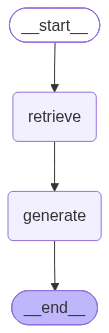

{'query': 'LangGraph', 'logs': ['retrieve: LangGraph', 'generate: LangGraph'], 'result': '关于《LangGraph》的回答'}


In [7]:
# 用 Pydantic BaseModel 描述状态：每次更新都会做校验 / 转换
class PydanticState(BaseModel):
    # Field(...) 表示必填；min_length=1 限制最短长度；description 用于生成 JSON Schema
    query: str = Field(..., min_length=1, description="用户问题")
    # reducer 依旧生效：Pydantic 会忽略 add 元数据，LangGraph 用它做追加
    logs: Annotated[list[str], add] = Field(default_factory=list)
    result: str = ""                  # 有默认值

    @field_validator("query")         # 声明一个针对 query 的校验器
    @classmethod
    def strip_query(cls, v: str) -> str:
        v = v.strip()                 # 去掉首尾空格
        if not v:
            raise ValueError("query 不能为空白")   # 抛错 -> 外层收到 ValidationError
        return v                      # 返回清洗后的值

    # 节点 1：检索。用 @classmethod 把节点函数收进状态类，cls 接收类本身
    @classmethod
    def retrieve(cls, state: "PydanticState") -> dict:
        return {"logs": [f"retrieve: {state.query}"]}

    # 节点 2：生成
    @classmethod
    def generate(cls, state: "PydanticState") -> dict:
        return {
            "logs": [f"generate: {state.query}"],
            "result": f"关于《{state.query}》的回答",
        }


# 组装并编译图
py_builder = StateGraph(PydanticState)
py_builder.add_node("retrieve", PydanticState.retrieve)
py_builder.add_node("generate", PydanticState.generate)
py_builder.add_edge(START, "retrieve")
py_builder.add_edge("retrieve", "generate")
py_builder.add_edge("generate", END)

py_graph = py_builder.compile()
show(py_graph)

print(py_graph.invoke({"query": "LangGraph"}))


### 关键特性：校验、转换、约束

- **运行时校验**：缺字段、类型不合法、违反约束都会立刻抛 `ValidationError`；
- **自动转换**（coercion）：`"10"` 会自动变成 `10`；
- **清洗逻辑**：`field_validator` 里做的事会在每次更新时执行（上面把首尾空格去掉了）。

In [8]:
# 1) 校验失败：query 全为空格，被 field_validator 拦下并抛 ValidationError
try:
    PydanticState(query="   ")
except ValidationError as e:
    print("校验失败：\n", e)

# 2) 清洗逻辑：field_validator 自动去掉首尾空格
print("清洗后:", repr(PydanticState(query="  LangGraph  ").query))

# 3) 自动类型转换：传入字符串 "10"，Pydantic 会转成 int
class NumState(BaseModel):
    count: int

print("自动转换:", NumState(count="10").count, type(NumState(count="10").count))

# 4) 约束生效：ge=1 / le=4096 限制取值范围，越界直接报错
class RangedState(BaseModel):
    max_tokens: int = Field(default=256, ge=1, le=4096)

try:
    RangedState(max_tokens=99999)
except ValidationError as e:
    print("越界失败：\n", e)


校验失败：
 1 validation error for PydanticState
query
  Value error, query 不能为空白 [type=value_error, input_value='   ', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error
清洗后: 'LangGraph'
自动转换: 10 <class 'int'>
越界失败：
 1 validation error for RangedState
max_tokens
  Input should be less than or equal to 4096 [type=less_than_equal, input_value=99999, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/less_than_equal


### Pydantic 优缺点

**优点**
- **运行时强校验**：把错误挡在图的最外层，极大提升健壮性。
- **自动类型转换 + 默认值 + 约束 + 自定义校验器**，数据清洗一站式。
- 序列化/反序列化、JSON Schema 生成开箱即用，适合对接 LLM 结构化输出 / API。
- IDE 自动补全、属性访问体验最好。

**缺点**
- **每次状态更新都要校验**，性能是三者中最低的（字段多、图步数多时更明显）。
- 引入额外概念（`Field`、validator、`ValidationError`），学习成本最高。
- 校验严格在快速迭代时可能“太吵”，需要额外处理异常。
- 相比纯 dict 少了一点自由（比如临时塞未声明字段会被拒绝）。

> 适合：**对外部输入不信任、需要强约束/清洗、要序列化或与 LLM 结构化输出对接**的场景。

---
## 4. 三种方式对比一览

| 维度 | TypedDict | dataclass | Pydantic BaseModel |
| --- | --- | --- | --- |
| 依赖 | 标准库 | 标准库 | 第三方（已是 LangGraph 依赖） |
| 本质 | `dict` | 普通对象 | 模型对象 |
| 读状态 | `state["k"]` | `state.k` | `state.k` |
| 节点返回值 | `dict` | `dict` | `dict` |
| 运行时校验 | ❌ | ❌ | ✅ |
| 自动类型转换 | ❌ | ❌ | ✅ |
| 字段默认值 | ❌（需初始传入） | ✅ | ✅ |
| 自定义校验/清洗 | ❌ | 手动 `__post_init__` | ✅ `field_validator` |
| reducer (`Annotated`) | ✅ | ✅ | ✅ |
| JSON Schema / 序列化 | 弱 | 需手动 | ✅ 开箱即用 |
| 性能 | 最快 | 较快 | 最慢（有校验开销） |
| 学习/使用成本 | 最低 | 中 | 最高 |
| 典型场景 | 内部高性能编排 | 想要默认值+属性访问 | 外部输入/强约束/序列化 |

## 5. 选择建议

1. **默认从 `TypedDict` 开始**：官方示例、性能最好、和 LangGraph 最贴合。
2. 需要**默认值或属性访问**、又不想引入 Pydantic → 换 `dataclass`。
3. 满足以下任一条件，用 **Pydantic**：
   - 状态里含有**用户/LLM 直接产生的不可信数据**；
   - 需要**自动类型转换、范围约束、字段清洗**；
   - 需要把状态**序列化为 JSON** 或生成 **JSON Schema**（如 structured output）。
4. 三种方式**可以混用 reducers**：凡是需要“追加/合并”的字段，统一用
   `Annotated[类型, 归约函数]`，行为与选哪种 state 定义无关。
5. 性能敏感且字段很多时，优先 TypedDict；正确性/健壮性优先时，优先 Pydantic。

> 一句话：**TypedDict 快、dataclass 顺手、Pydantic 安全**。按“数据可信度 + 是否需要序列化”来选。